In [1]:
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

SEED = 42
np.random.seed(SEED)

df = pd.read_csv("../user_movie_rates.csv")
df.head()

,user_id,movie_id,rating,datetime
0,1,1193,5,2000-12-31 22:12:40+00:00
1,1,661,3,2000-12-31 22:35:09+00:00
2,1,914,3,2000-12-31 22:32:48+00:00
3,1,3408,4,2000-12-31 22:04:35+00:00
4,1,2355,5,2001-01-06 23:38:11+00:00


In [2]:
df["datetime"] = pd.to_datetime(df["datetime"])

In [3]:
len(df)

948367

Превращаем таблицу рейтингов в граф взаимодействий

Формируем семантику “позитивного сигнала”. Однако, у разных пользователей шкала оценки субъективна и выбор порога для позитивного сигнала не очевидна. Пользователь, которому понравился фильм, вполне может оценить его на 3, сравнивая его относительно других фильмов, которые ему понравились больше. Также, считаем как данность тот факт, что пользователь не поставит самую низкую оценку фильму, который ему понравился.

Тогда выдвигаем ряд гипотез, по которым пороговое значение может быть одно из следующих [3.0, 4.0, 5.0]

Формируем минимальный объём пользовательского сигнала, необходимый для построения устойчивого профиля пользователя.

При малом числе позитивных взаимодействий (например, 4–5 фильмов) структура его связей в графе может быть недостаточно информативной, что затрудняет обучение качественного эмбеддинга.
Предполагаем, что увеличение числа исторических позитивных взаимодействий пользователя позволит DeepWalk точнее встроить его в графовую структуру и повысить качество рекомендаций.

Тогда выдвигаем гипотезу о влиянии минимального числа позитивных оценок пользователя на итоговые метрики качества и рассматриваем значения min_pos ∈ [5, 10, 20].

In [4]:
from typing import Dict, Optional
from common.data_prep import build_edges, filter_users_min_pos

THRESHOLDS = [3.0, 4.0, 5.0]
MIN_POS_LIST = [5, 10, 20]

experiments: Dict[str, pd.DataFrame] = {}

for t in THRESHOLDS:
    df_pos_thr = build_edges(df, threshold=t)

    for mp in MIN_POS_LIST:
        df_pos = filter_users_min_pos(df_pos_thr, min_pos=mp)

        name = f"thr_{t:.1f}_minpos_{mp}"
        experiments[name] = df_pos

        print(
            f"{name:20s} | "
            f"edges={len(df_pos):8d} | "
            f"users={df_pos['user_id'].nunique():6d} | "
            f"movies={df_pos['movie_id'].nunique():6d}"
        )

thr_3.0_minpos_5     | edges=  794223 | users=  6038 | movies=  3264
thr_3.0_minpos_10    | edges=  794183 | users=  6033 | movies=  3264
thr_3.0_minpos_20    | edges=  788215 | users=  5673 | movies=  3261
thr_4.0_minpos_5     | edges=  545628 | users=  6033 | movies=  3197
thr_4.0_minpos_10    | edges=  544897 | users=  5937 | movies=  3196
thr_4.0_minpos_20    | edges=  531904 | users=  5083 | movies=  3189
thr_5.0_minpos_5     | edges=  212898 | users=  5614 | movies=  2944
thr_5.0_minpos_10    | edges=  206814 | users=  4746 | movies=  2940
thr_5.0_minpos_20    | edges=  186161 | users=  3282 | movies=  2920


In [5]:
from common.data_prep import interactions_stats

for name, df_pos in experiments.items():
    s = interactions_stats(df_pos)
    print(f"\n{name}")
    print(s)


thr_3.0_minpos_5
users_total    6038.0
min               6.0
p25              36.0
median           77.0
p75             168.0
max            1827.0
users_lt5         0.0
users_lt10        5.0
users_lt20      365.0
dtype: float64

thr_3.0_minpos_10
users_total    6033.0
min              10.0
p25              36.0
median           77.0
p75             168.0
max            1827.0
users_lt5         0.0
users_lt10        0.0
users_lt20      360.0
dtype: float64

thr_3.0_minpos_20
users_total    5673.0
min              20.0
p25              41.0
median           85.0
p75             178.0
max            1827.0
users_lt5         0.0
users_lt10        0.0
users_lt20        0.0
dtype: float64

thr_4.0_minpos_5
users_total    6033.0
min               5.0
p25              26.0
median           55.0
p75             117.0
max            1334.0
users_lt5         0.0
users_lt10       96.0
users_lt20      950.0
dtype: float64

thr_4.0_minpos_10
users_total    5937.0
min              10.0
p25        

Разделяем данные на обучающую и тестовую выборки в пропорции 80/20 с сохранением хронологии внутри каждого пользователя. 
Для каждого пользователя более ранние взаимодействия отправляются в обучение, а последние 20% по времени используются для тестирования. 
Такой сценарий лучше соответствует реальной постановке задачи рекомендаций: модель обучается на прошлом поведении и предсказывает будущие взаимодействия.

In [6]:
from common.split import temporal_train_test_split


splits = {}
for name, df_pos in experiments.items():
    train_df, test_df = temporal_train_test_split(
        df_pos,
        user_col="user_id",
        time_col="datetime",
        test_ratio=0.2,
        min_train=1,
        min_test=1,
    )

    splits[(name, "80_20")] = (train_df, test_df)

    print(
        f"{name:20s} | "
        f"train={len(train_df):7d} | test={len(test_df):7d} | "
        f"users_train={train_df['user_id'].nunique():5d} | users_test={test_df['user_id'].nunique():5d}"
    )


thr_3.0_minpos_5     | train= 632944 | test= 161279 | users_train= 6038 | users_test= 6038
thr_3.0_minpos_10    | train= 632914 | test= 161269 | users_train= 6033 | users_test= 6033
thr_3.0_minpos_20    | train= 628284 | test= 159931 | users_train= 5673 | users_test= 5673
thr_4.0_minpos_5     | train= 434116 | test= 111512 | users_train= 6033 | users_test= 6033
thr_4.0_minpos_10    | train= 433568 | test= 111329 | users_train= 5937 | users_test= 5937
thr_4.0_minpos_20    | train= 423522 | test= 108382 | users_train= 5083 | users_test= 5083
thr_5.0_minpos_5     | train= 168107 | test=  44791 | users_train= 5614 | users_test= 5614
thr_5.0_minpos_10    | train= 163580 | test=  43234 | users_train= 4746 | users_test= 4746
thr_5.0_minpos_20    | train= 147627 | test=  38534 | users_train= 3282 | users_test= 3282


In [68]:
!pip install networkx

Преобразуем обучающую выборку в двудольный граф пользователь–фильм. 
Чтобы исключить коллизии идентификаторов, пользовательские и товарные вершины хранятся в разных пространствах имён: `u_<id>` и `i_<id>`.
Дополнительно проверяем, что исходные числовые ID пользователей и фильмов не пересекаются, а итоговые строковые идентификаторы действительно различимы.

In [11]:
import networkx as nx

def build_bipartite_graph(train_edges, user_col="user_id", item_col="movie_id"):
    G = nx.Graph()

    user_nodes = [f"u_{int(u)}" for u in train_edges[user_col].unique()]
    item_nodes = [f"i_{int(i)}" for i in train_edges[item_col].unique()]

    G.add_nodes_from(user_nodes, bipartite="users")
    G.add_nodes_from(item_nodes, bipartite="items")

    for u, i in train_edges[[user_col, item_col]].itertuples(index=False):
        G.add_edge(f"u_{int(u)}", f"i_{int(i)}")

    return G

first_split_name = next(iter(splits))

Генерируем последовательности случайных блужданий по графу. 
Для повышения устойчивости эмбеддингов увеличиваем длину проходов и число блужданий на вершину, чтобы модель чаще наблюдала локальное и более дальнее окружение узлов.

In [7]:
def generate_random_walks(G, walk_length=20, walks_per_node=10, seed=42):
    rng = np.random.default_rng(seed)
    nodes = list(G.nodes())
    walks = []

    for _ in range(walks_per_node):
        rng.shuffle(nodes)
        for start in nodes:
            walk = [start]
            cur = start
            for _ in range(walk_length - 1):
                neigh = list(G.neighbors(cur))
                if not neigh:
                    break
                cur = neigh[rng.integers(0, len(neigh))]
                walk.append(cur)
            walks.append(walk)
    return walks

In [71]:
!pip install gensim

In [8]:
from gensim.models import Word2Vec

def train_deepwalk(
    walks,
    dim=128,
    window=5,
    epochs=10,
    workers=4,
    seed=42,
    negative=5,
    ns_exponent=1.0,
):
    model = Word2Vec(
        sentences=walks,
        vector_size=dim,
        window=window,
        min_count=0,
        sg=1,          # skip-gram
        hs=0,
        negative=negative,
        ns_exponent=ns_exponent,
        workers=workers,
        seed=seed,
        epochs=epochs,
    )
    return model


Реализуем метрики качетсва РС с точки зрения полноты и точности.

- NDCG@K
- HitRate@K
- Recall@K

In [9]:
def _ap_at_k(ranked, gt, k):
    hits = 0
    s = 0.0
    for idx, item in enumerate(ranked[:k], start=1):
        if item in gt:
            hits += 1
            s += hits / idx
    return 0.0 if hits == 0 else s / min(len(gt), k)

def _ndcg_at_k(ranked, gt, k):
    dcg = 0.0
    for idx, item in enumerate(ranked[:k], start=1):
        if item in gt:
            dcg += 1.0 / np.log2(idx + 1)
    ideal_len = min(len(gt), k)
    if ideal_len == 0:
        return 0.0
    ideal = sum(1.0 / np.log2(i + 1) for i in range(1, ideal_len + 1))
    return dcg / ideal

def _mrr_at_k(ranked, gt, k):
    for idx, item in enumerate(ranked[:k], start=1):
        if item in gt:
            return 1.0 / idx
    return 0.0

In [10]:

def evaluate_ranking(
    model,
    train_edges,
    test_edges,
    user_col="user_id",
    item_col="movie_id",
    k_list=(5, 10, 20),
    sample_negatives=500,
    seed=42,
    user_vector_mode="history_avg",
):
    rng = np.random.default_rng(seed)

    users_all = sorted(train_edges[user_col].unique().astype(int).tolist())
    items = sorted(train_edges[item_col].unique().astype(int).tolist())
    items = [i for i in items if f"i_{i}" in model.wv]

    item_set = set(items)
    item_index = {it: idx for idx, it in enumerate(items)}

    gt_raw = test_edges.groupby(user_col)[item_col].apply(lambda s: set(map(int, s.tolist()))).to_dict()
    seen_raw = train_edges.groupby(user_col)[item_col].apply(lambda s: list(map(int, s.tolist()))).to_dict()

    I = np.vstack([model.wv[f"i_{i}"] for i in items])
    I /= np.maximum(np.linalg.norm(I, axis=1, keepdims=True), 1e-12)

    def build_user_vector(u: int):
        if user_vector_mode == "node" and f"u_{u}" in model.wv:
            vec = model.wv[f"u_{u}"].copy()
            norm = np.linalg.norm(vec)
            return vec / max(norm, 1e-12)

        hist_items = [it for it in seen_raw.get(u, []) if it in item_set]
        if not hist_items:
            return None

        hist_vecs = np.vstack([model.wv[f"i_{it}"] for it in hist_items])
        vec = hist_vecs.mean(axis=0)

        if user_vector_mode == "hybrid" and f"u_{u}" in model.wv:
            vec = 0.5 * vec + 0.5 * model.wv[f"u_{u}"]

        norm = np.linalg.norm(vec)
        return vec / max(norm, 1e-12)

    rows = []
    for u in users_all:
        if u not in gt_raw:
            continue

        gt_u = set(it for it in gt_raw[u] if it in item_set)
        if not gt_u:
            continue

        seen_u = set(it for it in seen_raw.get(u, []) if it in item_set)
        user_vec = build_user_vector(u)
        if user_vec is None:
            continue

        neg_pool = list((item_set - seen_u) - gt_u)

        if sample_negatives is None:
            candidates = list(item_set - seen_u)
        else:
            if len(neg_pool) > sample_negatives:
                neg = rng.choice(neg_pool, size=sample_negatives, replace=False).tolist()
            else:
                neg = neg_pool
            candidates = list(gt_u) + neg

        cand_idx = np.fromiter((item_index[it] for it in candidates), dtype=int)
        scores = I[cand_idx] @ user_vec
        ranked = [candidates[j] for j in np.argsort(-scores)]

        for k in k_list:
            topk = ranked[:k]
            hits = sum(1 for x in topk if x in gt_u)
            rows.append({
                "k": k,
                "precision": hits / k,
                "recall": hits / len(gt_u),
                "map": _ap_at_k(ranked, gt_u, k),
                "ndcg": _ndcg_at_k(ranked, gt_u, k),
                "mrr": _mrr_at_k(ranked, gt_u, k),
                "hitrate": 1.0 if hits > 0 else 0.0,
            })

    out = pd.DataFrame(rows).groupby("k").mean(numeric_only=True).reset_index()
    return out


In [75]:
def run_all_experiments(
    splits,
    experiments_order=None,
    split_keys=("80_20",),
    seed=42,
    walk_length=40,
    walks_per_node=20,
    dim=128,
    window=8,
    epochs=12,
    workers=4,
    negative=10,
    ns_exponent=1.0,
    user_vector_mode="history_avg",
    k_list=(5, 10, 20),
    sample_negatives=None,
):
    all_rows = []

    if experiments_order is None:
        exp_names = sorted({k[0] for k in splits.keys()})
        def sort_key(name: str):
            parts = name.split("_")
            thr = float(parts[1])
            mp = int(parts[3])
            return (thr, mp)
        experiments_order = sorted(exp_names, key=sort_key)

    for name in experiments_order:
        for split_key in split_keys:
            train_df, test_df = splits[(name, split_key)]

            G = build_bipartite_graph(train_df)
            walks = generate_random_walks(
                G,
                walk_length=walk_length,
                walks_per_node=walks_per_node,
                seed=seed,
            )
            dw = train_deepwalk(
                walks,
                dim=dim,
                window=window,
                epochs=epochs,
                workers=workers,
                seed=seed,
                negative=negative,
                ns_exponent=ns_exponent,
            )

            summary = evaluate_ranking(
                dw,
                train_df,
                test_df,
                k_list=k_list,
                sample_negatives=sample_negatives,
                seed=seed,
                user_vector_mode=user_vector_mode,
            )

            parts = name.split("_")
            thr_val = float(parts[1])
            min_pos_val = int(parts[3])

            summary.insert(0, "split", split_key)
            summary.insert(0, "user_vector_mode", user_vector_mode)
            summary.insert(0, "ns_exponent", ns_exponent)
            summary.insert(0, "negative", negative)
            summary.insert(0, "walks_per_node", walks_per_node)
            summary.insert(0, "walk_length", walk_length)
            summary.insert(0, "window", window)
            summary.insert(0, "epochs", epochs)
            summary.insert(0, "dim", dim)
            summary.insert(0, "min_pos", min_pos_val)
            summary.insert(0, "threshold", thr_val)

            summary["experiment"] = name
            summary["train_edges"] = len(train_df)
            summary["test_edges"] = len(test_df)
            summary["graph_nodes"] = G.number_of_nodes()
            summary["graph_edges"] = G.number_of_edges()

            all_rows.append(summary)

            print(
                f"Done: {name} {split_key} | "
                f"nodes={G.number_of_nodes()} edges={G.number_of_edges()} walks={len(walks)} | "
                f"user_vec={user_vector_mode} ns_exp={ns_exponent}"
            )

    return pd.concat(all_rows, ignore_index=True)


results_df = run_all_experiments(
    splits,
    experiments_order=None,
    split_keys=("80_20",),
    seed=42,
    walk_length=40,
    walks_per_node=20,
    dim=128,
    window=8,
    epochs=12,
    workers=4,
    negative=10,
    ns_exponent=1.0,
    k_list=(5, 10, 20),
    sample_negatives=None,
)

results_df


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Done: thr_3.0_minpos_5 80_20 | nodes=9259 edges=632944 walks=185180 | user_vec=history_avg ns_exp=1.0


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Done: thr_3.0_minpos_10 80_20 | nodes=9254 edges=632914 walks=185080 | user_vec=history_avg ns_exp=1.0


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

...

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Done: thr_5.0_minpos_10 80_20 | nodes=7556 edges=163580 walks=151120 | user_vec=history_avg ns_exp=1.0


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Done: thr_5.0_minpos_20 80_20 | nodes=6066 edges=147627 walks=121320 | user_vec=history_avg ns_exp=1.0


,threshold,min_pos,dim,epochs,window,walk_length,walks_per_node,negative,ns_exponent,user_vector_mode,split,k,precision,recall,map,ndcg,mrr,hitrate,experiment,train_edges,test_edges,graph_nodes,graph_edges
0,3.0,5,128,12,8,40,20,10,1.0,history_avg,80_20,5,0.105300,0.039840,0.064041,0.109666,0.203285,0.360550,thr_3.0_minpos_5,632944,161279,9259,632944
1,3.0,5,128,12,8,40,20,10,1.0,history_avg,80_20,10,0.100066,0.073161,0.053586,0.115204,0.225889,0.531136,thr_3.0_minpos_5,632944,161279,9259,632944
2,3.0,5,128,12,8,40,20,10,1.0,history_avg,80_20,20,0.092224,0.128470,0.051676,0.130866,0.237216,0.695098,thr_3.0_minpos_5,632944,161279,9259,632944
3,3.0,10,128,12,8,40,20,10,1.0,history_avg,80_20,5,0.107873,0.040411,0.064833,0.111340,0.203702,0.367147,thr_3.0_minpos_10,632914,161269,9254,632914
4,3.0,10,128,12,8,40,20,10,1.0,history_avg,80_20,10,0.101227,0.072924,0.054253,0.116157,0.225775,0.533234,thr_3.0_minpos_10,632914,161269,9254,632914
5,3.0,10,128,12,8,40,20,10,1.0,history_avg,80_20,20,0.092458,0.127365,0.051797,0.130963,0.236914,0.692524,thr_3.0_minpos_10,632914,161269,9254,632914
6,3.0,20,128,12,8,40,20,10,1.0,history_avg,80_20,5,0.111828,0.036786,0.066735,0.114152,0.209275,0.375639,thr_3.0_minpos_20,628284,159931,8892,628284
7,3.0,20,128,12,8,40,20,10,1.0,history_avg,80_20,10,0.103666,0.066393,0.053549,0.115786,0.230608,0.535519,thr_3.0_minpos_20,628284,159931,8892,628284
8,3.0,20,128,12,8,40,20,10,1.0,history_avg,80_20,20,0.095443,0.118015,0.050281,0.129301,0.242211,0.700335,thr_3.0_minpos_20,628284,159931,8892,628284
9,4.0,5,128,12,8,40,20,10,1.0,history_avg,80_20,5,0.084568,0.043714,0.050888,0.089712,0.166924,0.312780,thr_4.0_minpos_5,434116,111512,9168,434116


In [76]:
numeric_cols = ["precision", "recall", "map", "ndcg", "mrr", "hitrate"]
for col in numeric_cols:
    results_df[col] = pd.to_numeric(results_df[col])

results_df["k"] = pd.to_numeric(results_df["k"])
results_df["threshold"] = pd.to_numeric(results_df["threshold"])
results_df["min_pos"] = pd.to_numeric(results_df["min_pos"])

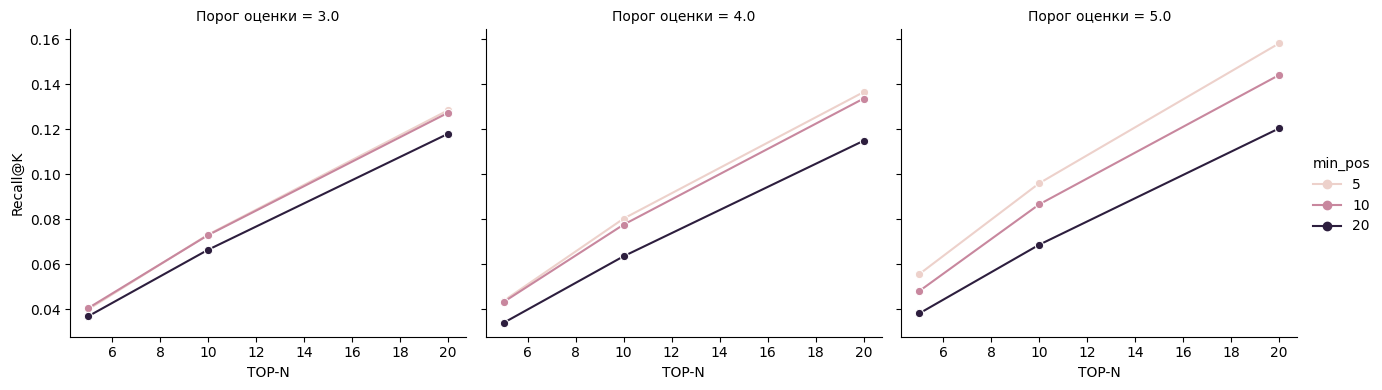

In [77]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.relplot(
    data=results_df,
    x="k",
    y="recall",
    hue="min_pos",
    col="threshold",
    kind="line",
    marker="o",
    height=4,
    aspect=1.1
)

g.set_axis_labels("TOP-N", "Recall@K")
g.set_titles("Порог оценки = {col_name}")
plt.show()

In [78]:
max_recall_per_k = results_df.loc[
    results_df.groupby("k")["recall"].idxmax()
].sort_values("k")[["threshold", "min_pos", "k", "recall"]]

max_recall_per_k

,threshold,min_pos,k,recall
18,5.0,5,5,0.055600
19,5.0,5,10,0.096031
20,5.0,5,20,0.158288


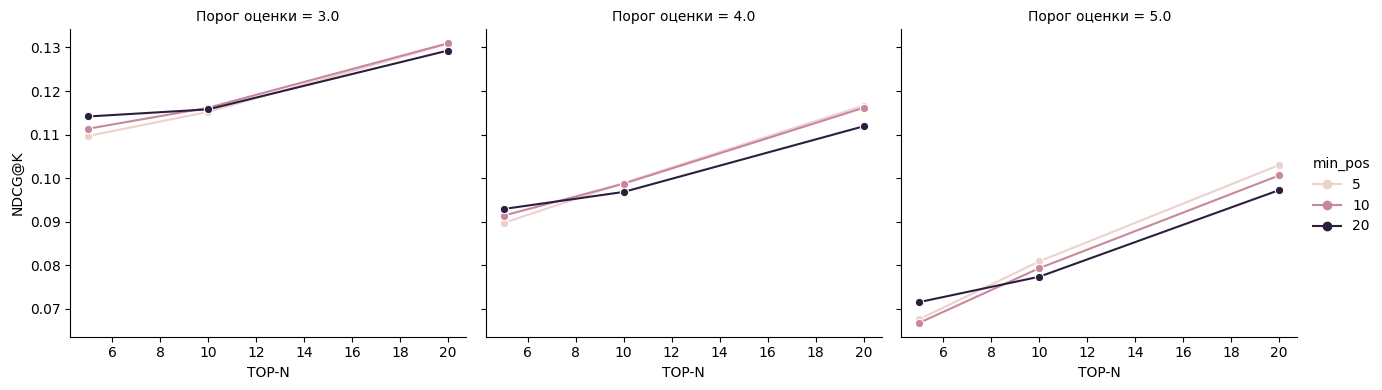

In [79]:
g = sns.relplot(
    data=results_df,
    x="k",
    y="ndcg",
    hue="min_pos",
    col="threshold",
    kind="line",
    marker="o",
    height=4,
    aspect=1.1
)

g.set_axis_labels("TOP-N", "NDCG@K")
g.set_titles("Порог оценки = {col_name}")
plt.show()

In [80]:
max_recall_per_k = results_df.loc[
    results_df.groupby("k")["ndcg"].idxmax()
].sort_values("k")[["threshold", "min_pos", "k", "ndcg"]]

max_recall_per_k

,threshold,min_pos,k,ndcg
6,3.0,20,5,0.114152
4,3.0,10,10,0.116157
5,3.0,10,20,0.130963


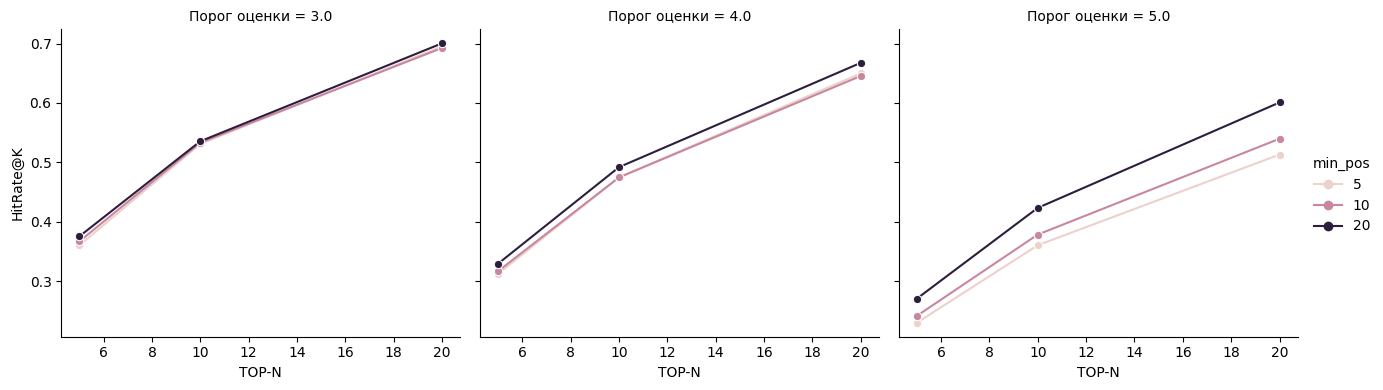

In [81]:
g = sns.relplot(
    data=results_df,
    x="k",
    y="hitrate",
    hue="min_pos",
    col="threshold",
    kind="line",
    marker="o",
    height=4,
    aspect=1.1
)

g.set_axis_labels("TOP-N", "HitRate@K")
g.set_titles("Порог оценки = {col_name}")
plt.show()

In [82]:
max_recall_per_k = results_df.loc[
    results_df.groupby("k")["hitrate"].idxmax()
].sort_values("k")[["threshold", "min_pos", "k", "hitrate"]]

max_recall_per_k

,threshold,min_pos,k,hitrate
6,3.0,20,5,0.375639
7,3.0,20,10,0.535519
8,3.0,20,20,0.700335


## В условиях Cold Start

In [12]:
from common.cold_start import make_synthetic_cold_start_split, summarize_split_result

### Оценка качества рекомендаций DeepWalk

По полученному списку рекомендаций рассчитываются метрики `Recall@K`, `NDCG@K` и `HitRate@K` для нескольких значений `K`. Итоговая таблица содержит средние значения метрик по всем пользователям, для которых удалось выполнить оценку.

In [13]:
from typing import Iterable


def evaluate_ranking_for_users(
        model,
        train_edges,
        test_edges,
        eval_users: Optional[Iterable[int]] = None,
        user_col="user_id",
        item_col="movie_id",
        k_list=(5, 10, 20),
        sample_negatives=500,
        seed=42,
        user_vector_mode="history_avg",
):
    rng = np.random.default_rng(seed)

    if eval_users is None:
        users_all = sorted(train_edges[user_col].unique().astype(int).tolist())
    else:
        users_all = sorted(set(map(int, eval_users)))

    items = sorted(train_edges[item_col].unique().astype(int).tolist())
    items = [i for i in items if f"i_{i}" in model.wv]

    item_set = set(items)
    item_index = {it: idx for idx, it in enumerate(items)}

    gt_raw = test_edges.groupby(user_col)[item_col].apply(lambda s: set(map(int, s.tolist()))).to_dict()
    seen_raw = train_edges.groupby(user_col)[item_col].apply(lambda s: list(map(int, s.tolist()))).to_dict()

    I = np.vstack([model.wv[f"i_{i}"] for i in items])
    I /= np.maximum(np.linalg.norm(I, axis=1, keepdims=True), 1e-12)

    def build_user_vector(u: int):
        if user_vector_mode == "node" and f"u_{u}" in model.wv:
            vec = model.wv[f"u_{u}"].copy()
            norm = np.linalg.norm(vec)
            return vec / max(norm, 1e-12)

        hist_items = [it for it in seen_raw.get(u, []) if it in item_set]
        if not hist_items:
            return None

        hist_vecs = np.vstack([model.wv[f"i_{it}"] for it in hist_items])
        vec = hist_vecs.mean(axis=0)

        if user_vector_mode == "hybrid" and f"u_{u}" in model.wv:
            vec = 0.5 * vec + 0.5 * model.wv[f"u_{u}"]

        norm = np.linalg.norm(vec)
        return vec / max(norm, 1e-12)

    rows = []
    users_evaluated = 0

    for u in users_all:
        if u not in gt_raw:
            continue

        gt_u = set(it for it in gt_raw[u] if it in item_set)
        if not gt_u:
            continue

        seen_u = set(it for it in seen_raw.get(u, []) if it in item_set)
        user_vec = build_user_vector(u)
        if user_vec is None:
            continue

        neg_pool = list((item_set - seen_u) - gt_u)

        if sample_negatives is None:
            candidates = list(item_set - seen_u)
        else:
            if len(neg_pool) > sample_negatives:
                neg = rng.choice(neg_pool, size=sample_negatives, replace=False).tolist()
            else:
                neg = neg_pool
            candidates = list(gt_u) + neg

        cand_idx = np.fromiter((item_index[it] for it in candidates), dtype=int)
        scores = I[cand_idx] @ user_vec
        ranked = [candidates[j] for j in np.argsort(-scores)]
        users_evaluated += 1

        for k in k_list:
            topk = ranked[:k]
            hits = sum(1 for x in topk if x in gt_u)
            rows.append({
                "k": k,
                "precision": hits / k,
                "recall": hits / len(gt_u),
                "map": _ap_at_k(ranked, gt_u, k),
                "ndcg": _ndcg_at_k(ranked, gt_u, k),
                "mrr": _mrr_at_k(ranked, gt_u, k),
                "hitrate": 1.0 if hits > 0 else 0.0,
            })

    if not rows:
        return pd.DataFrame(columns=["k", "precision", "recall", "map", "ndcg", "mrr", "hitrate", "users_evaluated"])

    out = pd.DataFrame(rows).groupby("k").mean(numeric_only=True).reset_index()
    out["users_evaluated"] = users_evaluated
    return out

### Запуск DeepWalk-экспериментов в условиях synthetic cold-start

Для проверки качества DeepWalk в условиях холодного старта проводится серия экспериментов с разным количеством доступных взаимодействий cold-start пользователя. Основным изменяемым параметром является `cold_n`, который задает, сколько первых взаимодействий пользователя остается в обучающей выборке.

Для каждого значения `cold_n` заново формируется synthetic cold-start разбиение. Пользователи, выбранные в cold-start группу, искусственно ограничиваются в обучающей выборке: модель видит только первые `cold_n` взаимодействий, а оставшаяся часть истории переносится в тестовую выборку. Таким образом моделируется ситуация, когда о пользователе известно очень мало, но требуется сформировать для него персонализированные рекомендации.

Для остальных пользователей используется стандартное временное разбиение. Их последние взаимодействия помещаются в тестовую выборку, а предыдущая история остается в обучающей. Эти пользователи сохраняются в обучающем графе и помогают модели формировать общую структуру связей между пользователями и фильмами.


In [14]:
def run_deepwalk_cold_start_experiments(
        base_df: pd.DataFrame,
        threshold: float,
        min_pos: int,
        cold_n_values=(1, 3, 5),
        cold_user_fraction: float = 0.2,
        min_interactions_for_cold: int = 20,
        warm_last_n: int = 1,
        seed: int = 42,
        walk_length: int = 40,
        walks_per_node: int = 20,
        dim: int = 128,
        window: int = 8,
        epochs: int = 12,
        workers: int = 4,
        negative: int = 10,
        ns_exponent: float = 1.0,
        user_vector_mode: str = "history_avg",
        k_list=(5, 10, 20),
        sample_negatives=None,
):
    cold_rows = []
    split_summaries = []

    for cold_n in cold_n_values:
        split_result = make_synthetic_cold_start_split(
            interactions=base_df,
            user_col="user_id",
            item_col="movie_id",
            time_col="datetime",
            cold_user_fraction=cold_user_fraction,
            cold_n=cold_n,
            min_interactions_for_cold=min_interactions_for_cold,
            warm_last_n=warm_last_n,
            random_state=seed,
        )

        train_df = split_result.train_df
        test_df = split_result.test_df
        eval_users = split_result.cold_users

        G = build_bipartite_graph(train_df)

        walks = generate_random_walks(
            G,
            walk_length=walk_length,
            walks_per_node=walks_per_node,
            seed=seed,
        )

        dw = train_deepwalk(
            walks,
            dim=dim,
            window=window,
            epochs=epochs,
            workers=workers,
            seed=seed,
            negative=negative,
            ns_exponent=ns_exponent,
        )

        summary = evaluate_ranking_for_users(
            model=dw,
            train_edges=train_df,
            test_edges=test_df,
            eval_users=eval_users,
            user_col="user_id",
            item_col="movie_id",
            k_list=k_list,
            sample_negatives=sample_negatives,
            seed=seed,
            user_vector_mode=user_vector_mode,
        )

        if len(summary) == 0:
            print(f"Skip cold_n={cold_n}: no evaluable users")
            continue

        summary.insert(0, "user_vector_mode", user_vector_mode)
        summary.insert(0, "ns_exponent", ns_exponent)
        summary.insert(0, "negative", negative)
        summary.insert(0, "walks_per_node", walks_per_node)
        summary.insert(0, "walk_length", walk_length)
        summary.insert(0, "window", window)
        summary.insert(0, "epochs", epochs)
        summary.insert(0, "dim", dim)
        summary.insert(0, "cold_n", cold_n)
        summary.insert(0, "cold_user_fraction", cold_user_fraction)
        summary.insert(0, "min_interactions_for_cold", min_interactions_for_cold)
        summary.insert(0, "warm_last_n", warm_last_n)
        summary.insert(0, "min_pos", min_pos)
        summary.insert(0, "threshold", threshold)

        summary["train_edges"] = len(train_df)
        summary["test_edges"] = len(test_df)
        summary["graph_nodes"] = G.number_of_nodes()
        summary["graph_edges"] = G.number_of_edges()
        summary["eligible_cold_users"] = len(split_result.eligible_cold_users)
        summary["cold_users"] = len(split_result.cold_users)

        split_summary = summarize_split_result(split_result)
        split_summary.insert(0, "cold_n", cold_n)
        split_summary.insert(0, "warm_last_n", warm_last_n)
        split_summary.insert(0, "min_pos", min_pos)
        split_summary.insert(0, "threshold", threshold)

        split_summaries.append(split_summary)
        cold_rows.append(summary)

        print(
            f"Done cold_n={cold_n} | train={len(train_df)} test={len(test_df)} | "
            f"cold_users={len(split_result.cold_users)} | "
            f"users_eval={int(summary['users_evaluated'].iloc[0])}"
        )

    cold_results_df = (
        pd.concat(cold_rows, ignore_index=True)
        if cold_rows
        else pd.DataFrame()
    )

    split_summary_df = (
        pd.concat(split_summaries, ignore_index=True)
        if split_summaries
        else pd.DataFrame()
    )

    return cold_results_df, split_summary_df

In [16]:
cold_results_df, split_summary_df = run_deepwalk_cold_start_experiments(
    base_df=df,
    threshold=4.0,
    min_pos=5,

    cold_n_values=(1, 3, 5),
    cold_user_fraction=0.2,
    min_interactions_for_cold=20,
    warm_last_n=1,

    seed=42,

    walk_length=40,
    walks_per_node=20,
    dim=128,
    window=8,
    epochs=12,
    workers=4,
    negative=10,
    ns_exponent=1.0,

    user_vector_mode="history_avg",
    k_list=(5, 10, 20),
    sample_negatives=None,
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Done cold_n=1 | train=751780 test=196587 | cold_users=1190 | users_eval=1190


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Done cold_n=3 | train=754160 test=194207 | cold_users=1190 | users_eval=1190


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Done cold_n=5 | train=756540 test=191827 | cold_users=1190 | users_eval=1190


In [17]:
agg_df = (
    cold_results_df
    .groupby(["cold_n", "k"])
    [["recall", "ndcg", "hitrate"]]
    .mean()
    .reset_index()
)

agg_df

,cold_n,k,recall,ndcg,hitrate
0,1,5,0.008855,0.216075,0.452101
1,1,10,0.015997,0.204180,0.543697
2,1,20,0.029349,0.192568,0.660504
3,3,5,0.009451,0.238323,0.492437
4,3,10,0.018341,0.230605,0.605882
5,3,20,0.033444,0.218422,0.710924
6,5,5,0.011579,0.271748,0.568067
7,5,10,0.022436,0.263028,0.670588
8,5,20,0.040780,0.250783,0.768067


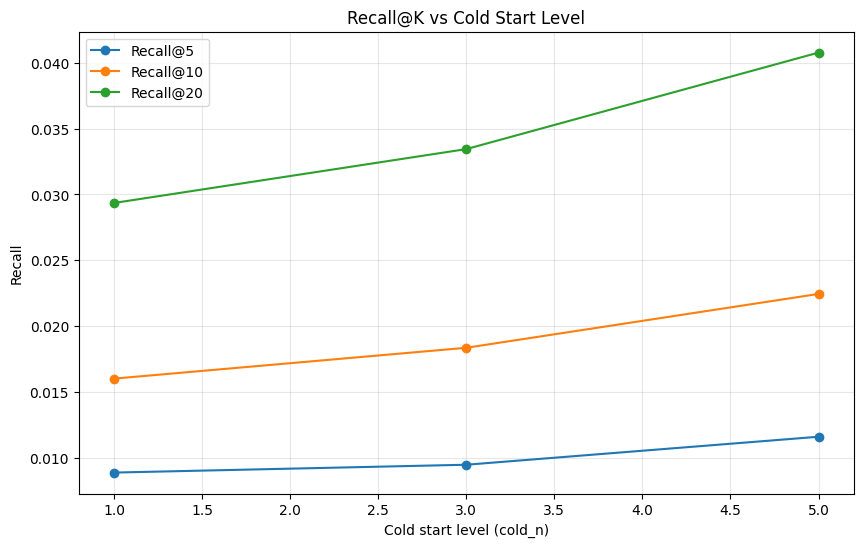

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for k in sorted(agg_df["k"].unique()):
    subset = agg_df[agg_df["k"] == k]
    plt.plot(subset["cold_n"], subset["recall"], marker="o", label=f"Recall@{k}")

plt.title("Recall@K vs Cold Start Level")
plt.xlabel("Cold start level (cold_n)")
plt.ylabel("Recall")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

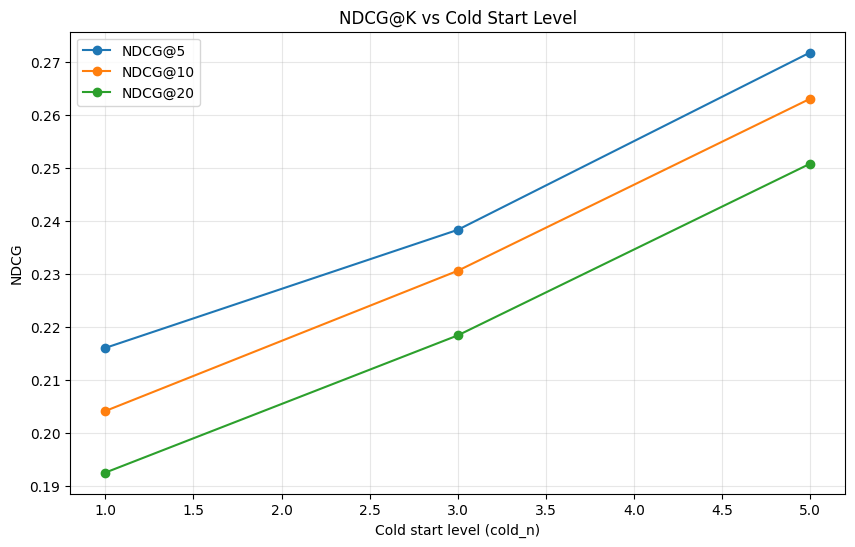

In [20]:
plt.figure(figsize=(10, 6))

for k in sorted(agg_df["k"].unique()):
    subset = agg_df[agg_df["k"] == k]
    plt.plot(subset["cold_n"], subset["ndcg"], marker="o", label=f"NDCG@{k}")

plt.title("NDCG@K vs Cold Start Level")
plt.xlabel("Cold start level (cold_n)")
plt.ylabel("NDCG")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

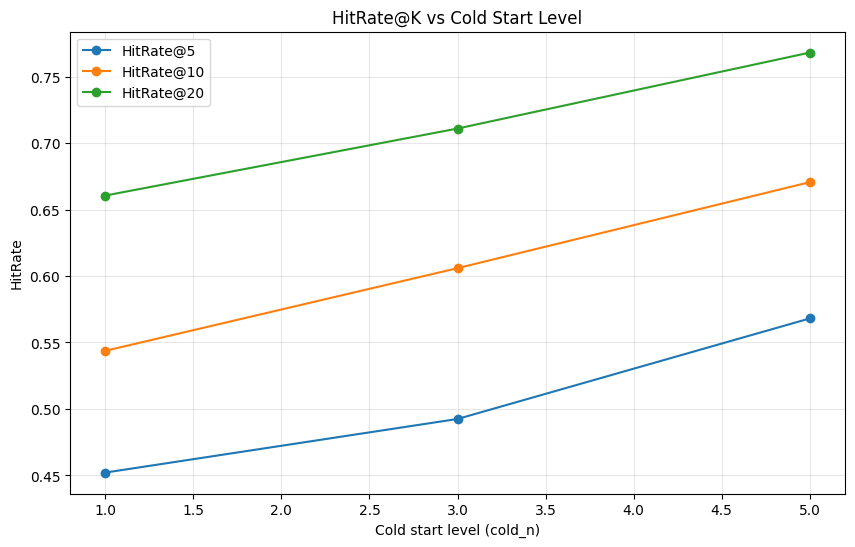

In [21]:
plt.figure(figsize=(10, 6))

for k in sorted(agg_df["k"].unique()):
    subset = agg_df[agg_df["k"] == k]
    plt.plot(subset["cold_n"], subset["hitrate"], marker="o", label=f"HitRate@{k}")

plt.title("HitRate@K vs Cold Start Level")
plt.xlabel("Cold start level (cold_n)")
plt.ylabel("HitRate")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()